In [2]:
#  Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Load the dataset
df = pd.read_excel("cleaned_dataset.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

The cleaned dataset contains 1200 records and 14 attributes.

In [5]:
# Dataset Overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [6]:
# Numerical Statistics
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [7]:
# Average order value
df["TotalPrice"].mean()

np.float64(1053.9683)

In [8]:
# Median order value ,useful because it is less affected by outliers.
df["TotalPrice"].median()

823.615

In [9]:
# Total transactions
df["OrderID"].count()

np.int64(1200)

Identify Trends

In [10]:
# Most Popular Products
df["Product"].value_counts()
# Printer was the most frequently ordered product

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [11]:
# Payment Methods
df["PaymentMethod"].value_counts()
# Online method is the most commonly used payment method.

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [12]:
# Order Status
df["OrderStatus"].value_counts()
# Order statuses are distributed relatively evenly across all categories, with Cancelled orders slightly higher than the others.

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [13]:
# referral sources
df["ReferralSource"].value_counts()
# Instagram generates the highest number of customer referrals.

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [14]:
# Monthly Sales Trend
# Create Month Column
# df["Month"] = df["Date"].dt.month
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

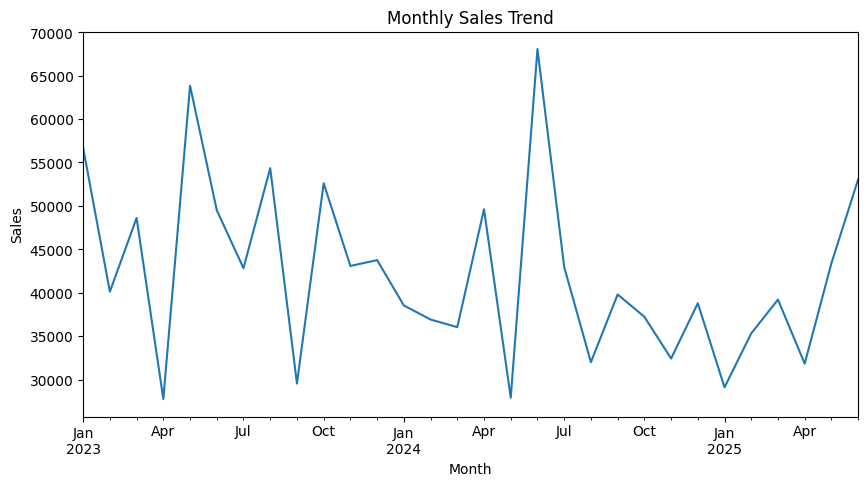

In [15]:
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

In [16]:
df["TotalPrice"].describe()
# The average order value is higher than the median order value, suggesting the presence of some high-value transactions that increase the overall average.
# The mean order value is considerably higher than the median order value, indicating the presence of a small number of high-value transactions that increase the overall average.
# Average money spent per order -ToralPrice mean

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

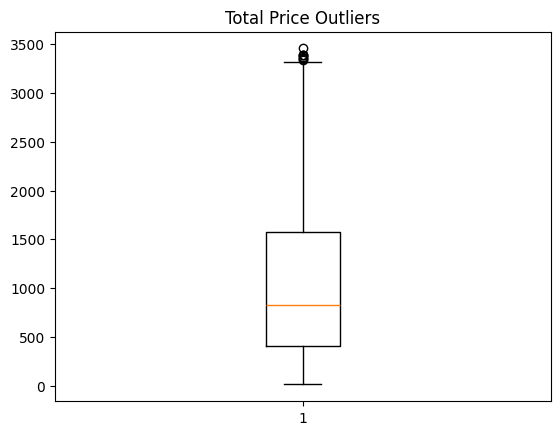

In [17]:
plt.boxplot(df["TotalPrice"])

plt.title("Total Price Outliers")
plt.show()

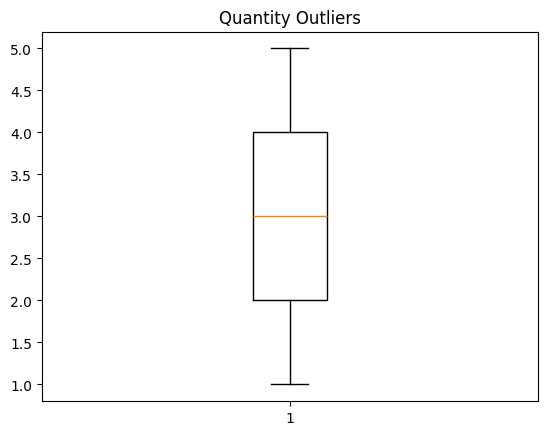

In [18]:
plt.boxplot(df["Quantity"])

plt.title("Quantity Outliers")
plt.show()

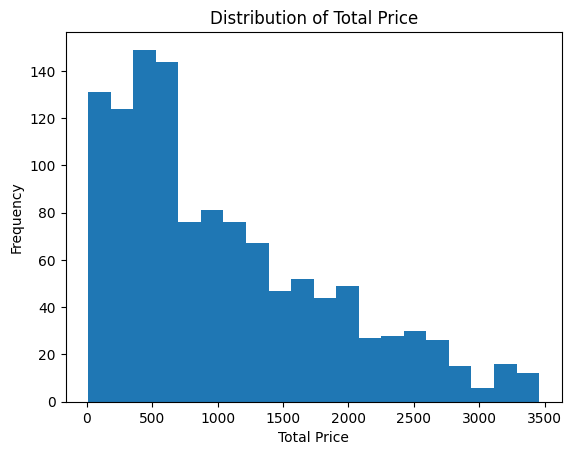

In [19]:
plt.hist(df["TotalPrice"], bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()
# Most transactions fall within a lower price range, while only a few orders have very high values.

In [20]:
df["CouponCode"].value_counts()

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [21]:
pd.crosstab(df["CouponCode"], df["OrderStatus"])

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
CouponCode,,,,,
FREESHIP,67,61,63,61,61
No Coupon,58,52,59,76,64
SAVE10,58,63,62,47,56
WINTER15,67,55,53,63,54


In [22]:
status_percentages = pd.crosstab(
    df["CouponCode"],
    df["OrderStatus"],
    normalize="index"
) * 100

status_percentages.round(2)

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
CouponCode,,,,,
FREESHIP,21.41,19.49,20.13,19.49,19.49
No Coupon,18.77,16.83,19.09,24.60,20.71
SAVE10,20.28,22.03,21.68,16.43,19.58
WINTER15,22.95,18.84,18.15,21.58,18.49


In [ ]:
# Returned
# Orders without coupons had the highest return rate (24.6%).
# Delivered
# SAVE10 orders had the highest delivery rate (22.03%).
# Cancelled
# WINTER15 orders had the highest cancellation rate (22.95%).

In [27]:
# Average spending by CouponCode
df.groupby("CouponCode")["TotalPrice"].mean().sort_values(ascending=False)
# Customers using WINTER15 have the highest average order value.Customers without coupons spend less than customers using promotional discounts
# Customers using the FREESHIP coupon had the highest average order value (1070.41), while WINTER15 users had the lowest average order value (1035.90).

CouponCode
FREESHIP     1070.405719
SAVE10       1065.874196
No Coupon    1043.370259
WINTER15     1035.902534
Name: TotalPrice, dtype: float64

In [28]:
# Total revenue by CouponCode
df.groupby("CouponCode")["TotalPrice"].sum().sort_values(ascending=False)
# FREESHIP generated the highest total revenue (335,036.99)

CouponCode
FREESHIP     335036.99
No Coupon    322401.41
SAVE10       304840.02
WINTER15     302483.54
Name: TotalPrice, dtype: float64

In [29]:
# Correlation
df[["Quantity","UnitPrice","TotalPrice"]].corr()
# Orders(Quantity) containing more items generally result in higher total sales values.
# Product unit price has a strong influence on total order value, suggesting that higher-priced products contribute significantly to revenue.
# The number of items purchased is largely independent of product price, indicating that customers do not necessarily buy fewer items when purchasing higher-priced products.

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,0.014553,0.615251
UnitPrice,0.014553,1.000000,0.717081
TotalPrice,0.615251,0.717081,1.000000


In [23]:
# Top Revenue Products
df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
# Earlier, Printer had the highest order count, but now Chair has the highest revenue.
# Although Printer was the most frequently ordered product, Chair generated the highest overall revenue. This suggests that order frequency does not necessarily translate into the highest sales revenue.

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [24]:
# Average Order Value by Payment Method
df.groupby("PaymentMethod")["TotalPrice"].mean().sort_values(ascending=False)
# Customers paying by Credit Card had the highest average order value, while Debit Card users had the lowest average order value.
# Higher-value purchases may be more likely to be completed using credit cards.

PaymentMethod
Credit Card    1127.553974
Gift Card      1070.973565
Cash           1056.041829
Online         1017.220698
Debit Card     1001.556810
Name: TotalPrice, dtype: float64

In [25]:
# Order Status Percentage
(df["OrderStatus"].value_counts(normalize=True)*100).round(2)
# Order statuses are distributed relatively evenly across all categories, with no single status dominating the dataset.

OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: proportion, dtype: float64

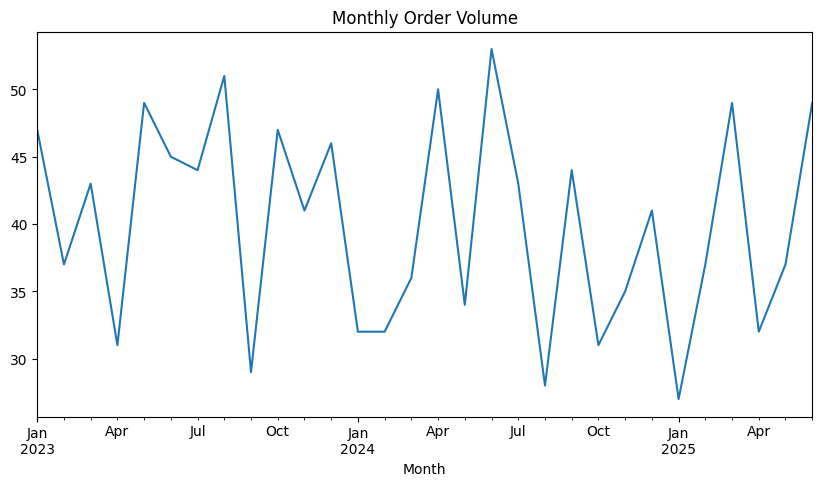

In [26]:
# Monthly Order Count
monthly_orders = df.groupby("Month")["OrderID"].count()

monthly_orders.plot(figsize=(10,5))
plt.title("Monthly Order Volume")
plt.show()